## Predictive Analytics - Bank Customer Churn

### Deskripsi Proyek
Bank XYZ mengalami tingkat churn pelanggan yang cukup tinggi dalam beberapa tahun terakhir. Proyek ini bertujuan untuk memprediksi apakah seorang pelanggan akan berhenti (churn) berdasarkan data historis mereka. Dengan pemodelan yang tepat, pihak bank dapat menargetkan pelanggan berisiko tinggi dan melakukan upaya retensi secara efektif.

### 1. Import Library

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### 2. Data Understanding
Data Understanding merupakan proses memahami informasi dalam data dan menentukan kualitas data tersebut.

#### 2.1 Data Loading
Data Loading merupakan tahap untuk memuat dataset yang akan digunakan agar dataset lebih mudah dipahami

*dataset yang digunakan dalam proyek ini:*

https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers

In [34]:
df = pd.read_csv("churn.csv")

**Insight**

Memuat dataset obesitas menggunakan fungsi pd.read_csv(). Data diambil dari file CSV yang berisi 10000 catatan dan 14 fitur. Pemeriksaan awal dilakukan untuk melihat beberapa baris pertama dan terakhir guna memastikan data berhasil dimuat dengan benar.

#### 2.2 Exploratory Data Analysis

Eksploratori data merupakan langkah pertama dalam menganalisa data yang bertujuan untuk mengenali ciri - ciri data, menemukan pola atau ketidakwajaran, dan menguji hipotesis yang ada. Tahap ini biasanya melibatkan penggunaan teknik statistik dan visualisasi grafik guna membantu dalam pemahaman data.

##### 2.2.1 EDA - Deskripsi Variabel

In [35]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [36]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [38]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


#### 2.2.2 EDA - Menangani Missing Value dan Menangani Outliers

In [39]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [40]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df =df.drop_duplicates()

**Insight**

Dilakukan pemeriksaan missing values dan duplikasi. Hasil pengecekan menunjukkan bahwa tidak ada missing values, namun terdapat beberapa duplikat yang kemudian dihapus untuk menjaga keunikan data.

In [43]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

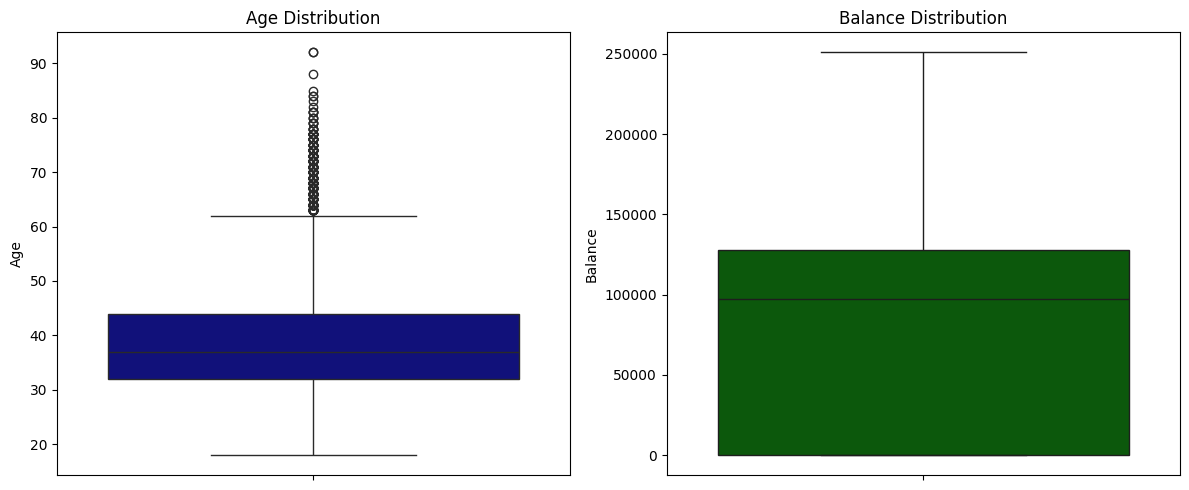

In [44]:
# Visualisasi distribusi Age dan Balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot untuk Age
sns.boxplot(y=df['Age'], ax=axes[0], color='darkblue')
axes[0].set_title('Age Distribution')
axes[0].set_ylabel('Age')

# Boxplot untuk Balance
sns.boxplot(y=df['Balance'], ax=axes[1], color='darkgreen')
axes[1].set_title('Balance Distribution')
axes[1].set_ylabel('Balance')

plt.tight_layout()
plt.show()

#### 2.2.3 EDA - Univariate Analysis

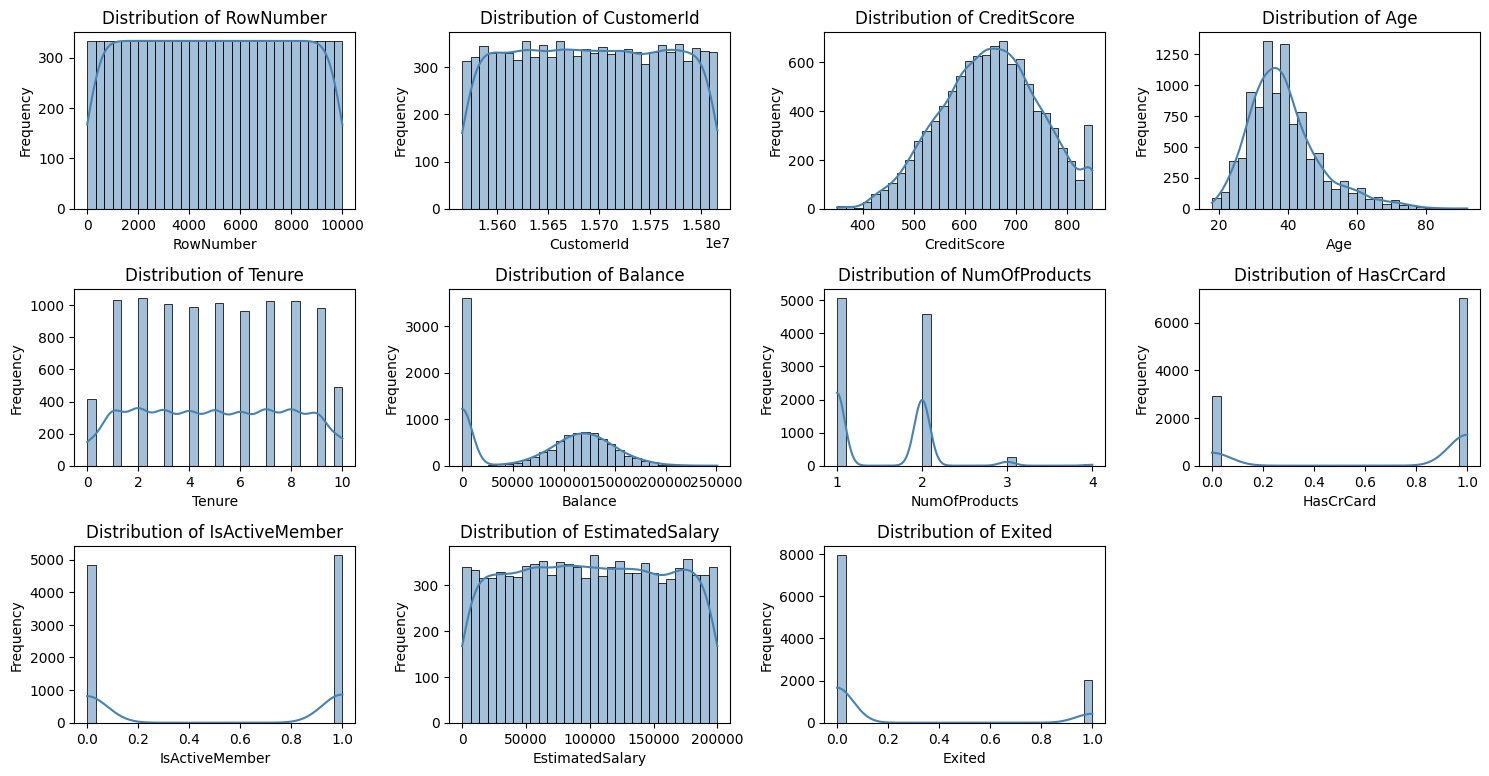

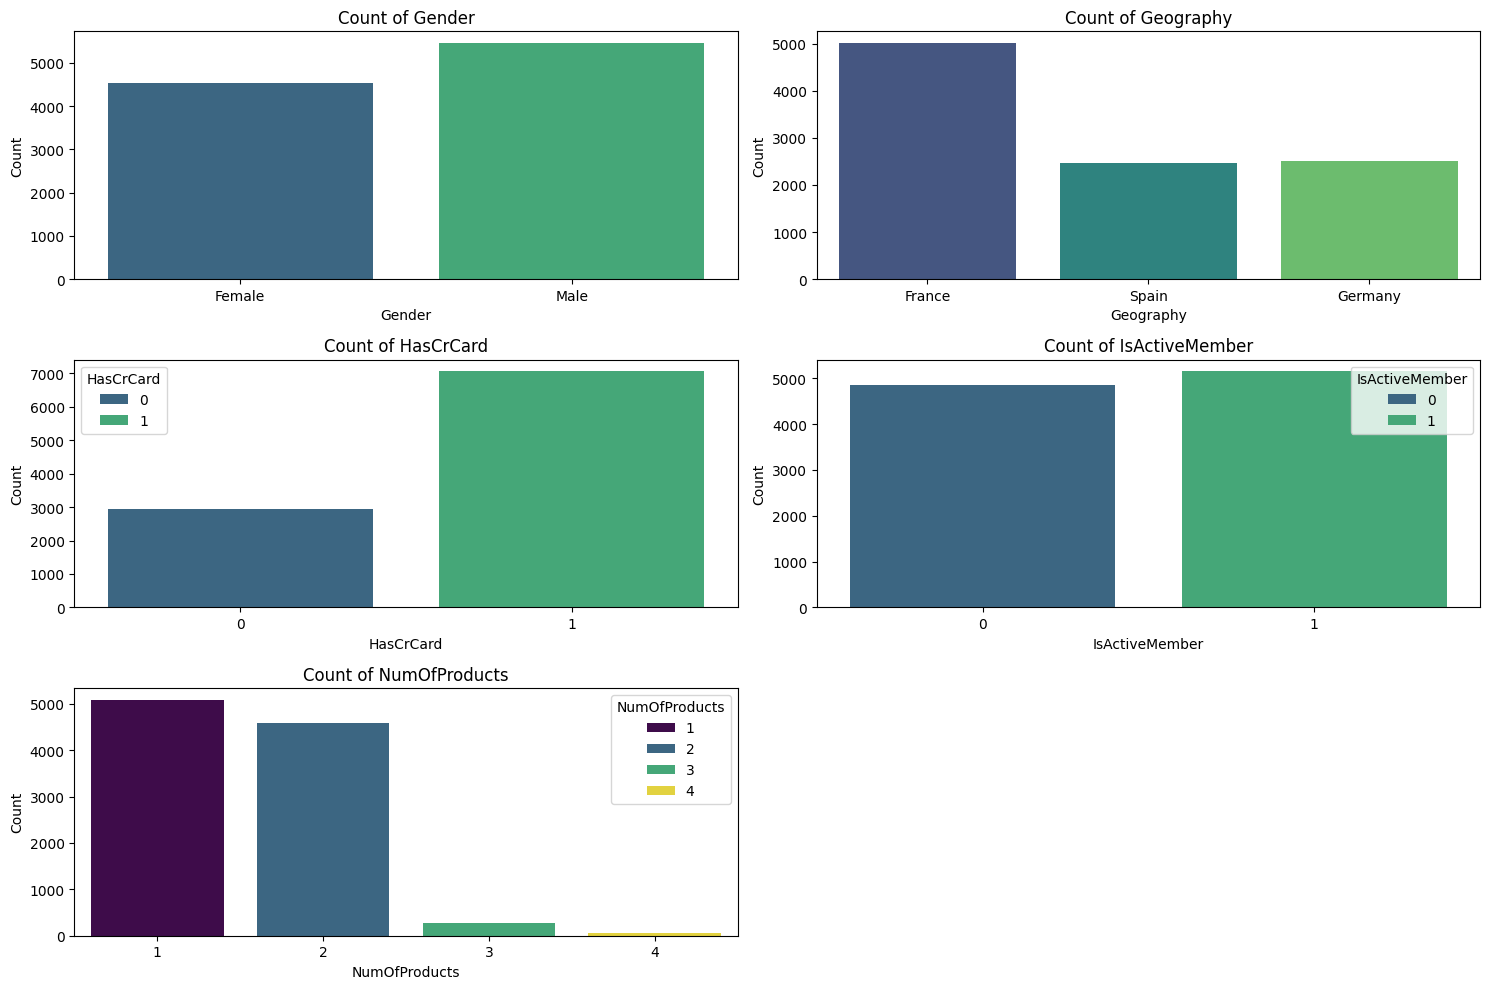

In [45]:
# 2.1 Univariate Analysis
# -------------------------
# Visualisasi distribusi variabel numerik dengan histogram
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Memilih kolom numerik dari dataset
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], bins=30, kde=True, color='steelblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Visualisasi count plot untuk variabel kategorikal
cat_cols = ['Gender', 'Geography', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue=col, data=df, palette="viridis")
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 2.2.4 Multivariate Analysis

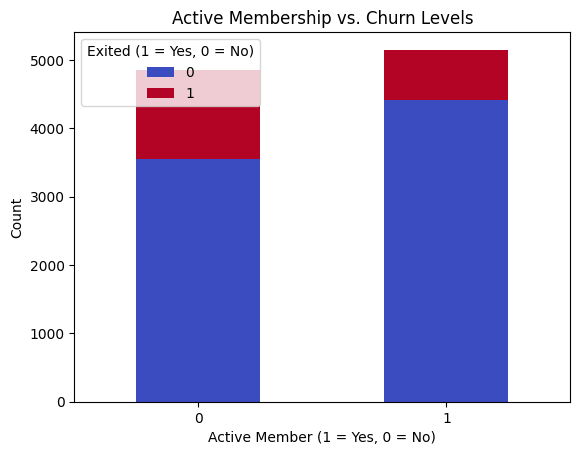

In [46]:
# Menghitung crosstab antara IsActiveMember dan Exited
crosstab = pd.crosstab(df['IsActiveMember'], df['Exited'])

# Membuat plot bar stacked
crosstab.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Active Membership vs. Churn Levels')
plt.xlabel('Active Member (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Mengatur rotasi label sumbu x
plt.legend(title='Exited (1 = Yes, 0 = No)')
plt.show()

<ipython-input-47-cad1c6a63bb5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NumOfProducts', y='Exited', data=df, palette='muted')


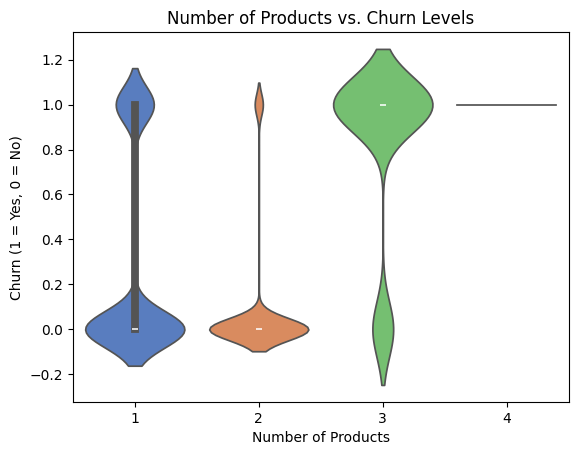

In [47]:
# Membuat violin plot untuk NumOfProducts dan Exited
sns.violinplot(x='NumOfProducts', y='Exited', data=df, palette='muted')
plt.title('Number of Products vs. Churn Levels')
plt.xlabel('Number of Products')
plt.ylabel('Churn (1 = Yes, 0 = No)')
plt.xticks(rotation=0)  # Mengatur rotasi label sumbu x
plt.show()

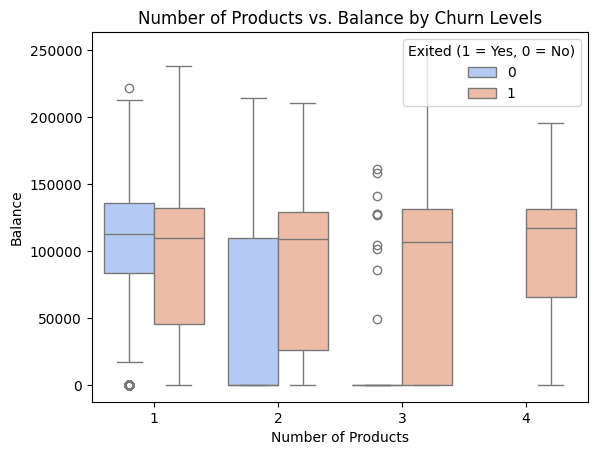

In [48]:
# Membuat boxplot untuk NumOfProducts dan Balance berdasarkan Exited
sns.boxplot(x='NumOfProducts', y='Balance', data=df, hue='Exited', palette='coolwarm')
plt.title('Number of Products vs. Balance by Churn Levels')
plt.xlabel('Number of Products')
plt.ylabel('Balance')
plt.legend(title='Exited (1 = Yes, 0 = No)')
plt.show()

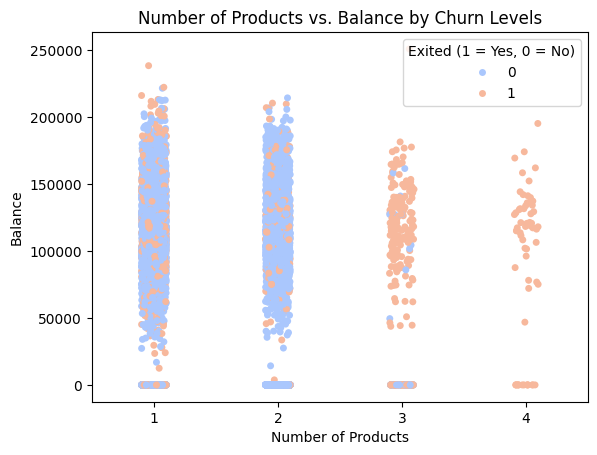

In [49]:
# Membuat strip plot untuk NumOfProducts dan Balance berdasarkan Exited
sns.stripplot(x='NumOfProducts', y='Balance', hue='Exited', data=df, palette='coolwarm', jitter=True)
plt.title('Number of Products vs. Balance by Churn Levels')
plt.xlabel('Number of Products')
plt.ylabel('Balance')
plt.legend(title='Exited (1 = Yes, 0 = No)')
plt.show()


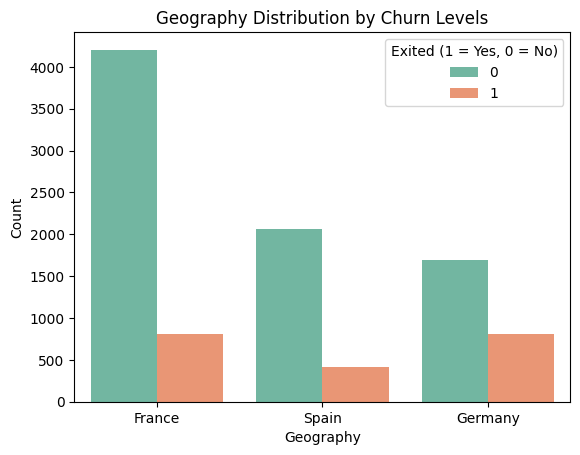

In [50]:
# Membuat count plot untuk Geography berdasarkan Exited
sns.countplot(x='Geography', hue='Exited', data=df, palette='Set2')
plt.title('Geography Distribution by Churn Levels')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.legend(title='Exited (1 = Yes, 0 = No)')
plt.show()

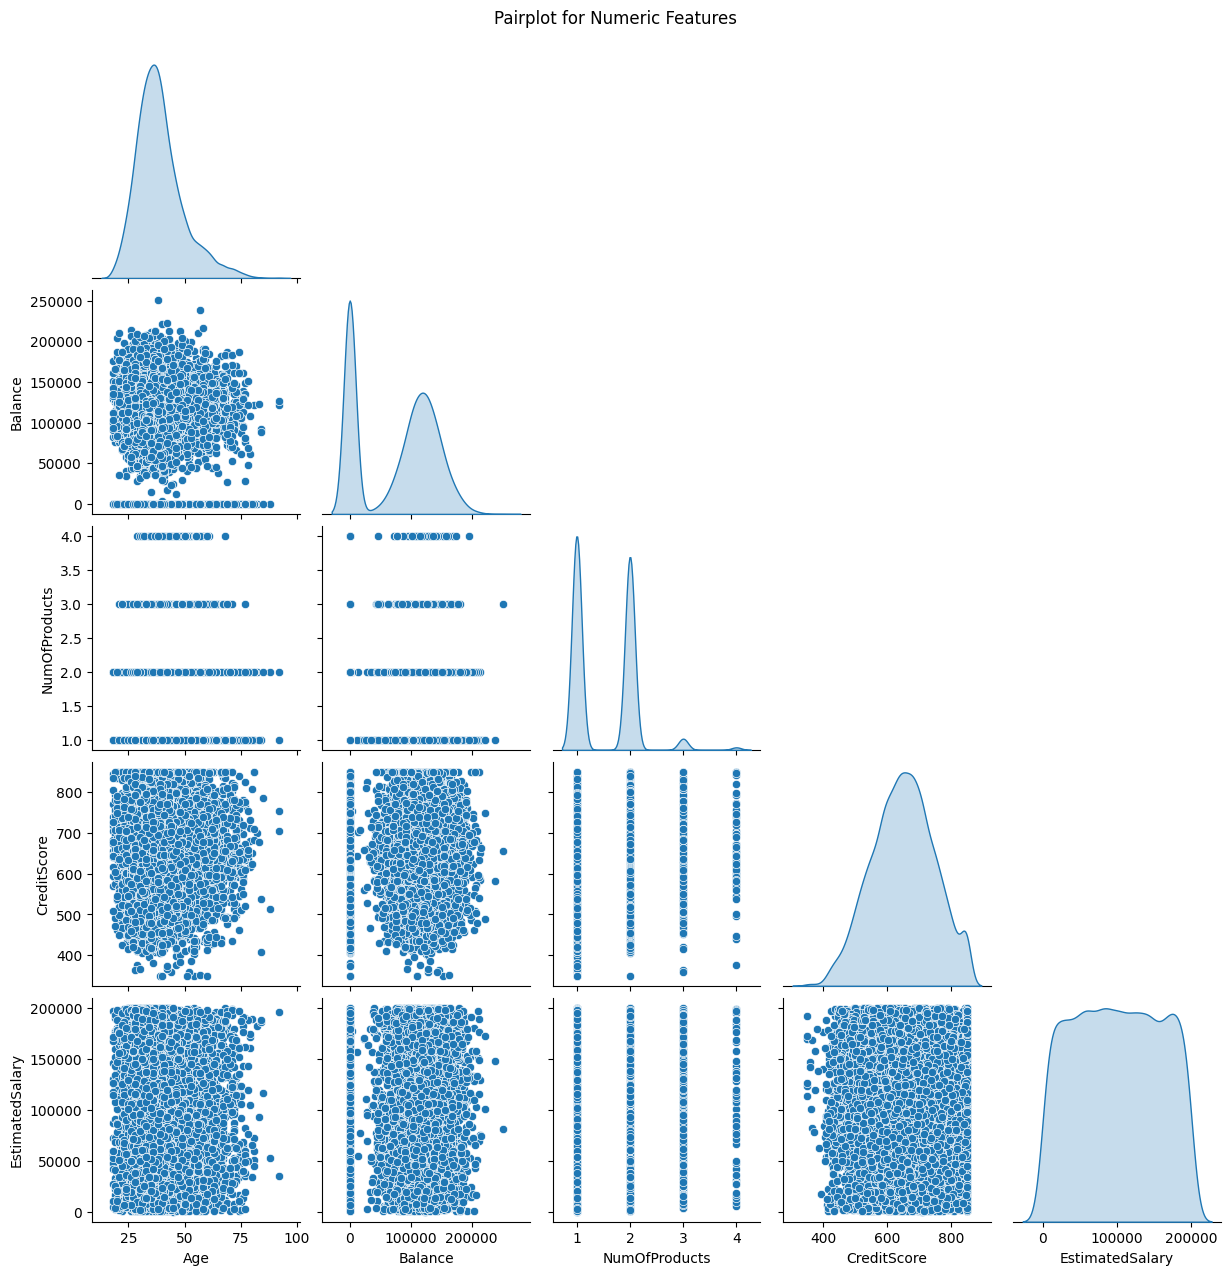

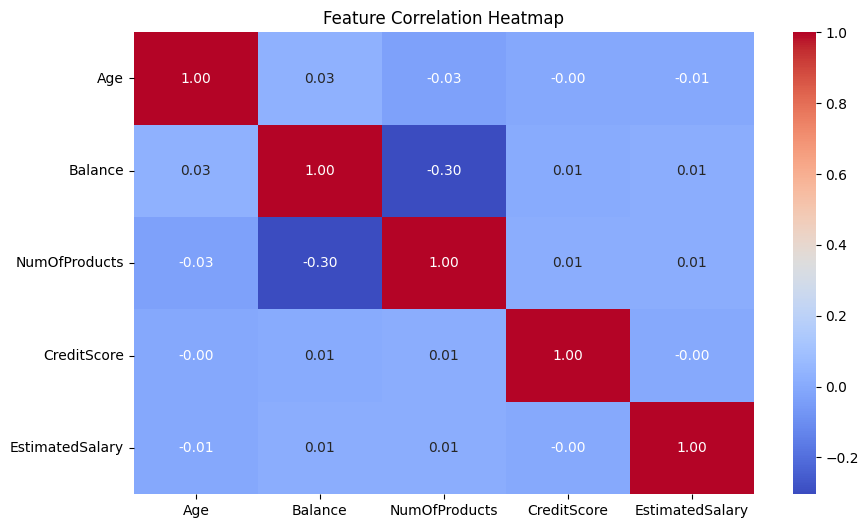

In [51]:
# 2.2 Multivariate Analysis
# ---------------------------
# Visualisasi pairplot untuk melihat hubungan antara variabel numerik
# Misalkan numeric_cols adalah daftar kolom numerik dalam dataset
numeric_cols = ['Age', 'Balance', 'NumOfProducts', 'CreditScore', 'EstimatedSalary']  # Ganti dengan kolom yang relevan

# Visualisasi pairplot untuk melihat hubungan antara variabel numerik
sns.pairplot(df[numeric_cols], diag_kind='kde', corner=True)
plt.suptitle("Pairplot for Numeric Features", y=1.02)
plt.show()

# Visualisasi Heatmap korelasi antar fitur
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**Insight**

Analisis eksplorasi data dilakukan untuk memahami distribusi dan hubungan antar variabel. Dari histogram, terlihat sebaran nilai pada setiap variabel numerik, sedangkan count plot menunjukkan frekuensi kategori pada variabel kategorikal. Insight penting yang diperoleh antara lain: tidak ada missing value, distribusi data cukup simetris pada sebagian besar fitur, dan terdapat beberapa outlier yang mungkin memerlukan perhatian lebih lanjut.

### 3. Data Preparation
Persiapan data adalah langkah yang dilakukan untuk mengolah data agar siap digunakan dalam tahap pembuatan model Machine Learning.

#### 3.1 Encoding Variabel Kategorikal

In [52]:
# Misalkan df adalah DataFrame Anda
le = LabelEncoder()

# Daftar kolom yang akan di-encode
categorical_cols = [
    "Gender",  # Contoh kolom untuk jenis kelamin
    "Geography",  # Contoh kolom untuk lokasi geografis
    "Exited"  # Kolom target untuk churn
]

# Melakukan encoding untuk setiap kolom dalam daftar
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Menampilkan DataFrame setelah encoding
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore  Geography  Gender  Age  \
0          1    15634602  Hargrave          619          0       0   42   
1          2    15647311      Hill          608          2       0   41   
2          3    15619304      Onio          502          0       0   42   
3          4    15701354      Boni          699          0       0   39   
4          5    15737888  Mitchell          850          2       0   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4      

#### 3.2 Pemisahan Fitur Target

In [53]:
# Misalkan df adalah DataFrame Anda
# Define x and y before encoding
x = df.drop(["Exited"], axis=1)  # Ganti "Exited" dengan kolom target yang sesuai
y = df["Exited"]  # Ganti "Exited" dengan kolom target yang sesuai

# Initialize label encoder
encoders = {}  # Dictionary to store encoders for each categorical column

# Encode only categorical columns
for col in x.columns:
    if x[col].dtype == 'object' or x[col].dtype.name == 'category':
        le = LabelEncoder()  # Create a new LabelEncoder for each column
        x[col] = le.fit_transform(x[col])
        encoders[col] = le  # Store the encoder for future use

print("Categorical encoding completed!")

Categorical encoding completed!


In [54]:
print(x.dtypes)

RowNumber            int64
CustomerId           int64
Surname              int64
CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object


In [55]:
# Create a LabelEncoder instance
le = LabelEncoder()

# Identify categorical columns (bins)
categorical_cols = [col for col in x.columns if x[col].dtype.name == 'category']

# Convert categorical columns to numeric
for col in categorical_cols:
    x[col] = le.fit_transform(x[col])

**Insight**

Mengubah variabel kategorikal ke format numerik menggunakan LabelEncoder

#### 3.3 Train-Test-Split

In [56]:
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

# Standardization
ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

#### 3.4 Standarisasi

In [57]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [58]:
print(x_train.dtype)

float64


**Insight**

menstandarisasi variabel numerik dengan StandardScaler. Transformasi ini penting agar model machine learning dapat memproses semua data secara konsisten.

#### 4. Model Development
Pengembangan model adalah fase di mana algoritma machine learning diterapkan untuk menyelesaikan permasalahan yang telah diidentifikasi pada tahap pemahaman bisnis.

In [59]:
# Define models dictionary
models = {
    "Random Forest Classifier": RandomForestClassifier(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "Ada Boost Classifier": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

# Verifikasi dictionary model
print("Defined Models:")
print(models)


Defined Models:
{'Random Forest Classifier': RandomForestClassifier(), 'Decision Tree Classifier': DecisionTreeClassifier(), 'Ada Boost Classifier': AdaBoostClassifier(), 'KNN': KNeighborsClassifier(), 'Gradient Boosting Classifier': GradientBoostingClassifier(), 'Logistic Regression': LogisticRegression(max_iter=1000)}


In [60]:

# Dictionary untuk menyimpan performa masing-masing model
results = {}

# Loop untuk training dan evaluasi setiap model
for name, model in models.items():
    # Training model
    model.fit(x_train, y_train)

    # Prediksi pada data testing
    y_pred = model.predict(x_test)

    # Menghitung metrik evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    # Simpan hasil evaluasi pada dictionary
    results[name] = {
       "accuracy": acc,
       "precision": prec,
       "recall": rec,
       "f1_score": f1,
       "confusion_matrix": cm
    }

    # Print hasil evaluasi untuk tiap model
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print("  Confusion Matrix:")
    print(cm)

# Menentukan model terbaik berdasarkan akurasi (atau metrik lain sesuai kebutuhan)
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
print(f"\nBest Model by Accuracy: {best_model_name}")




Random Forest Classifier:
  Accuracy: 0.8664
  Precision: 0.8590
  Recall: 0.8664
  F1 Score: 0.8513
  Confusion Matrix:
[[1944   59]
 [ 275  222]]

Decision Tree Classifier:
  Accuracy: 0.7820
  Precision: 0.7875
  Recall: 0.7820
  F1 Score: 0.7846
  Confusion Matrix:
[[1714  289]
 [ 256  241]]

Ada Boost Classifier:
  Accuracy: 0.8576
  Precision: 0.8465
  Recall: 0.8576
  F1 Score: 0.8446
  Confusion Matrix:
[[1917   86]
 [ 270  227]]

KNN:
  Accuracy: 0.8252
  Precision: 0.8027
  Recall: 0.8252
  F1 Score: 0.8014
  Confusion Matrix:
[[1908   95]
 [ 342  155]]

Gradient Boosting Classifier:
  Accuracy: 0.8684
  Precision: 0.8611
  Recall: 0.8684
  F1 Score: 0.8541
  Confusion Matrix:
[[1943   60]
 [ 269  228]]

Logistic Regression:
  Accuracy: 0.8128
  Precision: 0.7809
  Recall: 0.8128
  F1 Score: 0.7699
  Confusion Matrix:
[[1943   60]
 [ 408   89]]

Best Model by Accuracy: Gradient Boosting Classifier


**Insight**

Berbagai model dikembangkan untuk melakukan klasifikasi. Model-model yang digunakan antara lain Random Forest, Decision Tree, AdaBoost, KNN, Gradient Boosting, dan Logistic Regression. Evaluasi dilakukan dengan menghitung metrik seperti accuracy, precision, recall, F1 score, dan confusion matrix. Model Random Forest menunjukkan performa terbaik dengan akurasi tertinggi, yang mendukung keandalan model dalam membantu identifikasi individu berisiko tinggi.

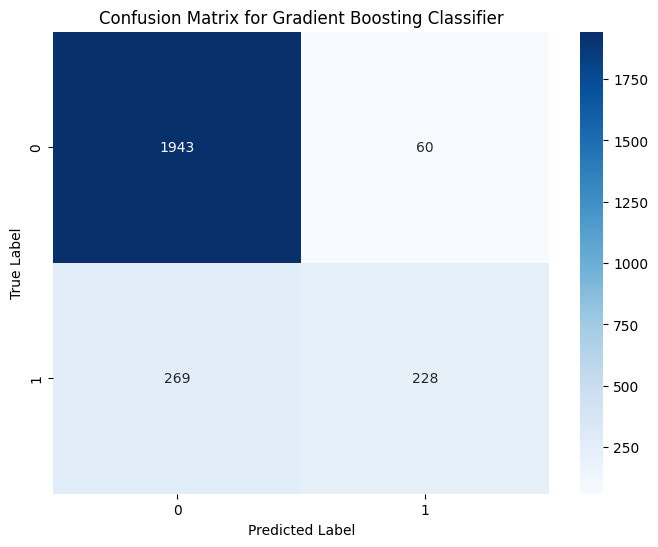

In [61]:
# Visualisasi Confusion Matrix untuk model terbaik
best_cm = results[best_model_name]["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix for {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**Insight**

Hasil evaluasi model divisualisasikan menggunakan heatmap untuk confusion matrix dan bar chart untuk perbandingan akurasi antar model. Visualisasi ini memudahkan analisis perbandingan kinerja setiap model, sehingga model dengan performa terbaik dapat diidentifikasi secara objektif.

**Conclusion**
Evaluasi model dilakukan untuk menentukan model yang paling sesuai dengan tujuan bisnis. Hasil evaluasi menunjukkan bahwa:

- Random Forest Classifier memiliki akurasi tertinggi (sekitar 87.04%) serta metrik evaluasi lain yang sangat baik, menjadikannya kandidat terbaik untuk prediksi tingkat obesitas.
- Model lain juga menunjukkan performa yang baik, namun sedikit di bawah model Random Forest.
- Decision Tree Classifier dan Logistic Regression menunjukkan performa yang lebih rendah dan tidak konsisten.
